# Chapter 32: Advanced Optimization Methods

This notebook explores **multi-objective optimization** and **scenario comparison**
for production optimization. We demonstrate Pareto front visualization for
conflicting objectives (maximize production vs minimize power) and compare
summer vs winter operating conditions.

In [1]:
# Execute against the selected, compiled NeqSim source checkout.
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import jpype

if not os.environ.get("NEQSIM_PROJECT_ROOT"):
    raise RuntimeError("Set NEQSIM_PROJECT_ROOT to the NeqSim source checkout before running.")
PROJECT_ROOT = Path(os.environ["NEQSIM_PROJECT_ROOT"]).resolve()
if not (PROJECT_ROOT / "devtools" / "neqsim_dev_setup.py").exists():
    raise RuntimeError("NEQSIM_PROJECT_ROOT must contain devtools/neqsim_dev_setup.py.")
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))
from neqsim_dev_setup import neqsim_init, neqsim_classes
ns = neqsim_classes(neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=False))
jneqsim = jpype.JPackage("neqsim")
NEQSIM_MODE = "devtools"
NOTEBOOK_PATH = Path(globals().get("__vsc_ipynb_file__", Path.cwd() / "ch22_advanced_optimization.ipynb")).resolve()
BOOK_ROOT = NOTEBOOK_PATH.parents[3]
FIGURES_DIR = NOTEBOOK_PATH.parent.parent / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
sys.path.insert(0, str(BOOK_ROOT / "devtools"))
from book_figure_tools import configure_figures, export_figure_summary
configure_figures()
print(f"NeqSim source: {PROJECT_ROOT}; Python: {sys.executable}")

# Named NeqSim class bindings used throughout the chapter.
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
SystemPrEos = jneqsim.thermo.system.SystemPrEos
SystemSrkCPAstatoil = jneqsim.thermo.system.SystemSrkCPAstatoil
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations
Stream = jneqsim.process.equipment.stream.Stream
Separator = jneqsim.process.equipment.separator.Separator
ThreePhaseSeparator = jneqsim.process.equipment.separator.ThreePhaseSeparator
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Heater = jneqsim.process.equipment.heatexchanger.Heater
HeatExchanger = jneqsim.process.equipment.heatexchanger.HeatExchanger
Mixer = jneqsim.process.equipment.mixer.Mixer
Splitter = jneqsim.process.equipment.splitter.Splitter
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Pump = jneqsim.process.equipment.pump.Pump
Expander = jneqsim.process.equipment.expander.Expander
Recycle = jneqsim.process.equipment.util.Recycle
ProcessSystem = jneqsim.process.processmodel.ProcessSystem


All NeqSim classes imported OK
NeqSim source: C:\Users\solbraa\OneDrive - NTNU\Documents\ChatGPT\NeqSim; Python: C:\Users\solbraa\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\python.exe


## 32.1 Multi-Objective Optimization: Concept

In production optimization, we often face **conflicting objectives**:

- **Maximize production rate** (revenue)
- **Minimize compressor power** (operating cost)
- **Minimize flaring/emissions**

No single operating point can optimize all objectives simultaneously. Instead,
we seek the **Pareto front** — the set of solutions where improving one objective
necessarily worsens another.

In [2]:
# Build a simple compression process at different throughputs
fluid = jneqsim.thermo.system.SystemSrkEos(273.15 + 30.0, 50.0)
fluid.addComponent("methane", 0.85)
fluid.addComponent("ethane", 0.08)
fluid.addComponent("propane", 0.04)
fluid.addComponent("CO2", 0.02)
fluid.addComponent("nitrogen", 0.01)
fluid.setMixingRule("classic")

flow_rates = np.linspace(30000, 120000, 10)  # kg/hr
comp_powers = []

for flow in flow_rates:
    feed = jneqsim.process.equipment.stream.Stream("Feed", fluid.clone())
    feed.setFlowRate(float(flow), "kg/hr")
    feed.setTemperature(30.0, "C")
    feed.setPressure(50.0, "bara")

    comp = jneqsim.process.equipment.compressor.Compressor("Compressor", feed)
    comp.setOutletPressure(120.0)

    proc = jneqsim.process.processmodel.ProcessSystem()
    proc.add(feed)
    proc.add(comp)
    proc.run()

    comp_powers.append(comp.getPower('kW'))

comp_powers = np.array(comp_powers)
print(f"Flow range: {flow_rates[0]/1000:.0f} - {flow_rates[-1]/1000:.0f} t/hr")
print(f"Power range: {comp_powers[0]/1000:.1f} - {comp_powers[-1]/1000:.1f} MW")

Flow range: 30 - 120 t/hr
Power range: 1.0 - 3.9 MW


## 32.2 Generate Pareto Front

We generate a Pareto front using NeqSim evaluations at three assumed polytropic efficiencies
to illustrate the trade-off between production rate and total compressor power consumption.

In [3]:
# All candidate points are full NeqSim compression simulations.
# Optimize two conflicting objectives: maximize throughput, minimize total power.
candidate_production, candidate_power, candidate_eta = [], [], []
for eta in [0.62, 0.70, 0.78]:
    for flow in flow_rates:
        candidate_feed = Stream("Pareto feed", fluid.clone())
        candidate_feed.setFlowRate(float(flow), "kg/hr")
        candidate_feed.run()
        candidate_comp = Compressor("Pareto compressor", candidate_feed)
        candidate_comp.setOutletPressure(120.0)
        candidate_comp.setUsePolytropicCalc(True)
        candidate_comp.setPolytropicEfficiency(float(eta))
        candidate_comp.run()
        candidate_production.append(float(candidate_comp.getOutletStream().getFlowRate("kg/hr"))/1000.0)
        candidate_power.append(float(candidate_comp.getPower("kW"))/1000.0)
        candidate_eta.append(eta)
production = np.asarray(candidate_production)
power = np.asarray(candidate_power)
is_pareto = np.asarray([not np.any((production >= q-1e-7) & (power <= w+1e-9) & ((production > q+1e-7) | (power < w-1e-9))) for q,w in zip(production,power)])
pareto_prod, pareto_power = production[is_pareto], power[is_pareto]
dom_prod, dom_power = production[~is_pareto], power[~is_pareto]
assert len(pareto_prod) >= 2 and np.all(np.isfinite(power))
print(f"Full NeqSim candidates: {len(production)}; non-dominated: {is_pareto.sum()}; dominated: {(~is_pareto).sum()}")


Full NeqSim candidates: 30; non-dominated: 10; dominated: 20


ch22_advanced_optimization.ipynb:cell6:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


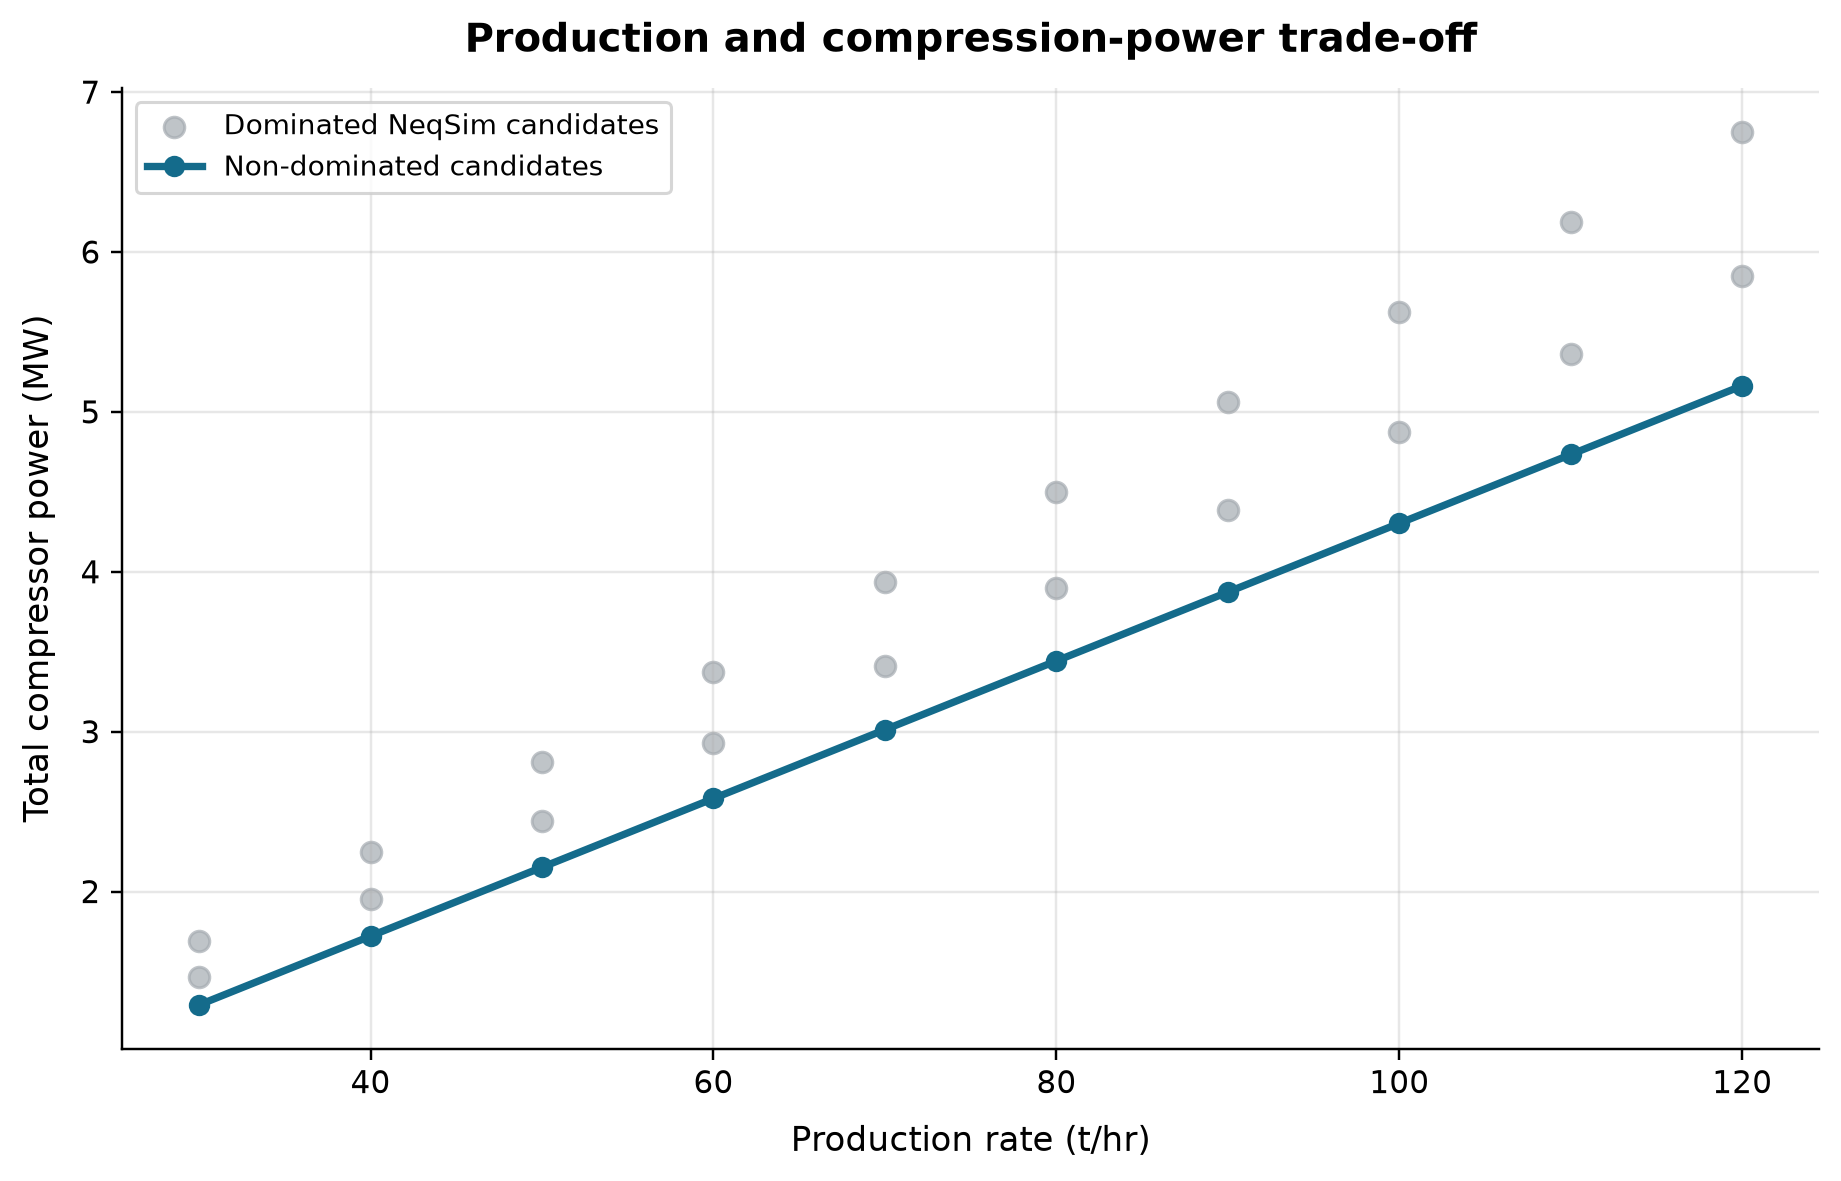

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.scatter(dom_prod, dom_power, c="#A5ABB1", s=45, alpha=0.7, label="Dominated NeqSim candidates")
sorted_idx = np.argsort(pareto_prod)
ax.plot(pareto_prod[sorted_idx], pareto_power[sorted_idx], "o-", linewidth=2.4, color="#146B8B", label="Non-dominated candidates")
ax.set(xlabel="Production rate (t/hr)", ylabel="Total compressor power (MW)", title="Production and compression-power trade-off")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ch22_pareto_front.png", dpi=220, bbox_inches="tight")
plt.show()


**Executed-figure discussion.** Non-dominated candidates: total compressor power spans 1.291–5.164 MW across the plotted cases. Dominated NeqSim candidates: total compressor power spans 1.463–6.75 MW across the plotted cases.

Every candidate is a NeqSim compressor simulation; higher throughput increases total shaft work, while the assumed efficiency changes that trade-off. Non-dominated points express a production-energy choice rather than an economic optimum. Apply verified efficiency maps, capacity limits and economic weights before choosing an operating point.


## 32.3 Scenario Comparison: Summer vs Winter

Ambient temperature affects cooling capacity and compressor power. We compare
key performance indicators for summer (30 °C) and winter (5 °C) conditions.

In [5]:
scenarios = {
    "Summer (30 C)": {"ambient_T": 30.0, "cooling_T": 40.0},
    "Winter (5 C)": {"ambient_T": 5.0, "cooling_T": 15.0},
}

results = {}

for name, params in scenarios.items():
    s_fluid = jneqsim.thermo.system.SystemSrkEos(273.15 + params["ambient_T"], 50.0)
    s_fluid.addComponent("methane", 0.85)
    s_fluid.addComponent("ethane", 0.08)
    s_fluid.addComponent("propane", 0.04)
    s_fluid.addComponent("CO2", 0.02)
    s_fluid.addComponent("nitrogen", 0.01)
    s_fluid.setMixingRule("classic")

    s_feed = jneqsim.process.equipment.stream.Stream("Feed", s_fluid)
    s_feed.setFlowRate(80000.0, "kg/hr")
    s_feed.setTemperature(float(params["ambient_T"]), "C")
    s_feed.setPressure(50.0, "bara")

    s_comp = jneqsim.process.equipment.compressor.Compressor("Compressor", s_feed)
    s_comp.setOutletPressure(120.0)

    s_cooler = jneqsim.process.equipment.heatexchanger.Cooler("Cooler", s_comp.getOutletStream())
    s_cooler.setOutTemperature(273.15 + params["cooling_T"])

    s_proc = jneqsim.process.processmodel.ProcessSystem()
    s_proc.add(s_feed)
    s_proc.add(s_comp)
    s_proc.add(s_cooler)
    s_proc.run()

    results[name] = {
        "Compressor Power [MW]": s_comp.getPower('kW') / 1000.0,
        "Discharge T [C]": s_comp.getOutletStream().getTemperature('C'),
        "Cooler Duty [MW]": abs(s_cooler.getDuty() / 1e6),
        "Export T [C]": s_cooler.getOutletStream().getTemperature('C'),
    }

    print(f"\n{name}:")
    for k, v in results[name].items():
        print(f"  {k}: {v:.2f}")


Summer (30 C):
  Compressor Power [MW]: 2.60
  Discharge T [C]: 97.34
  Cooler Duty [MW]: 3.67
  Export T [C]: 40.00

Winter (5 C):
  Compressor Power [MW]: 2.28
  Discharge T [C]: 70.13
  Cooler Duty [MW]: 3.78
  Export T [C]: 15.00


Metric | Summer | Winter | Difference (same unit)
Compressor Power [MW] | 2.5998 | 2.2841 | -0.3157
Discharge T [C] | 97.3403 | 70.1302 | -27.2101
Cooler Duty [MW] | 3.6717 | 3.7794 | +0.1078
Export T [C] | 40.0000 | 15.0000 | -25.0000


ch22_advanced_optimization.ipynb:cell9:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


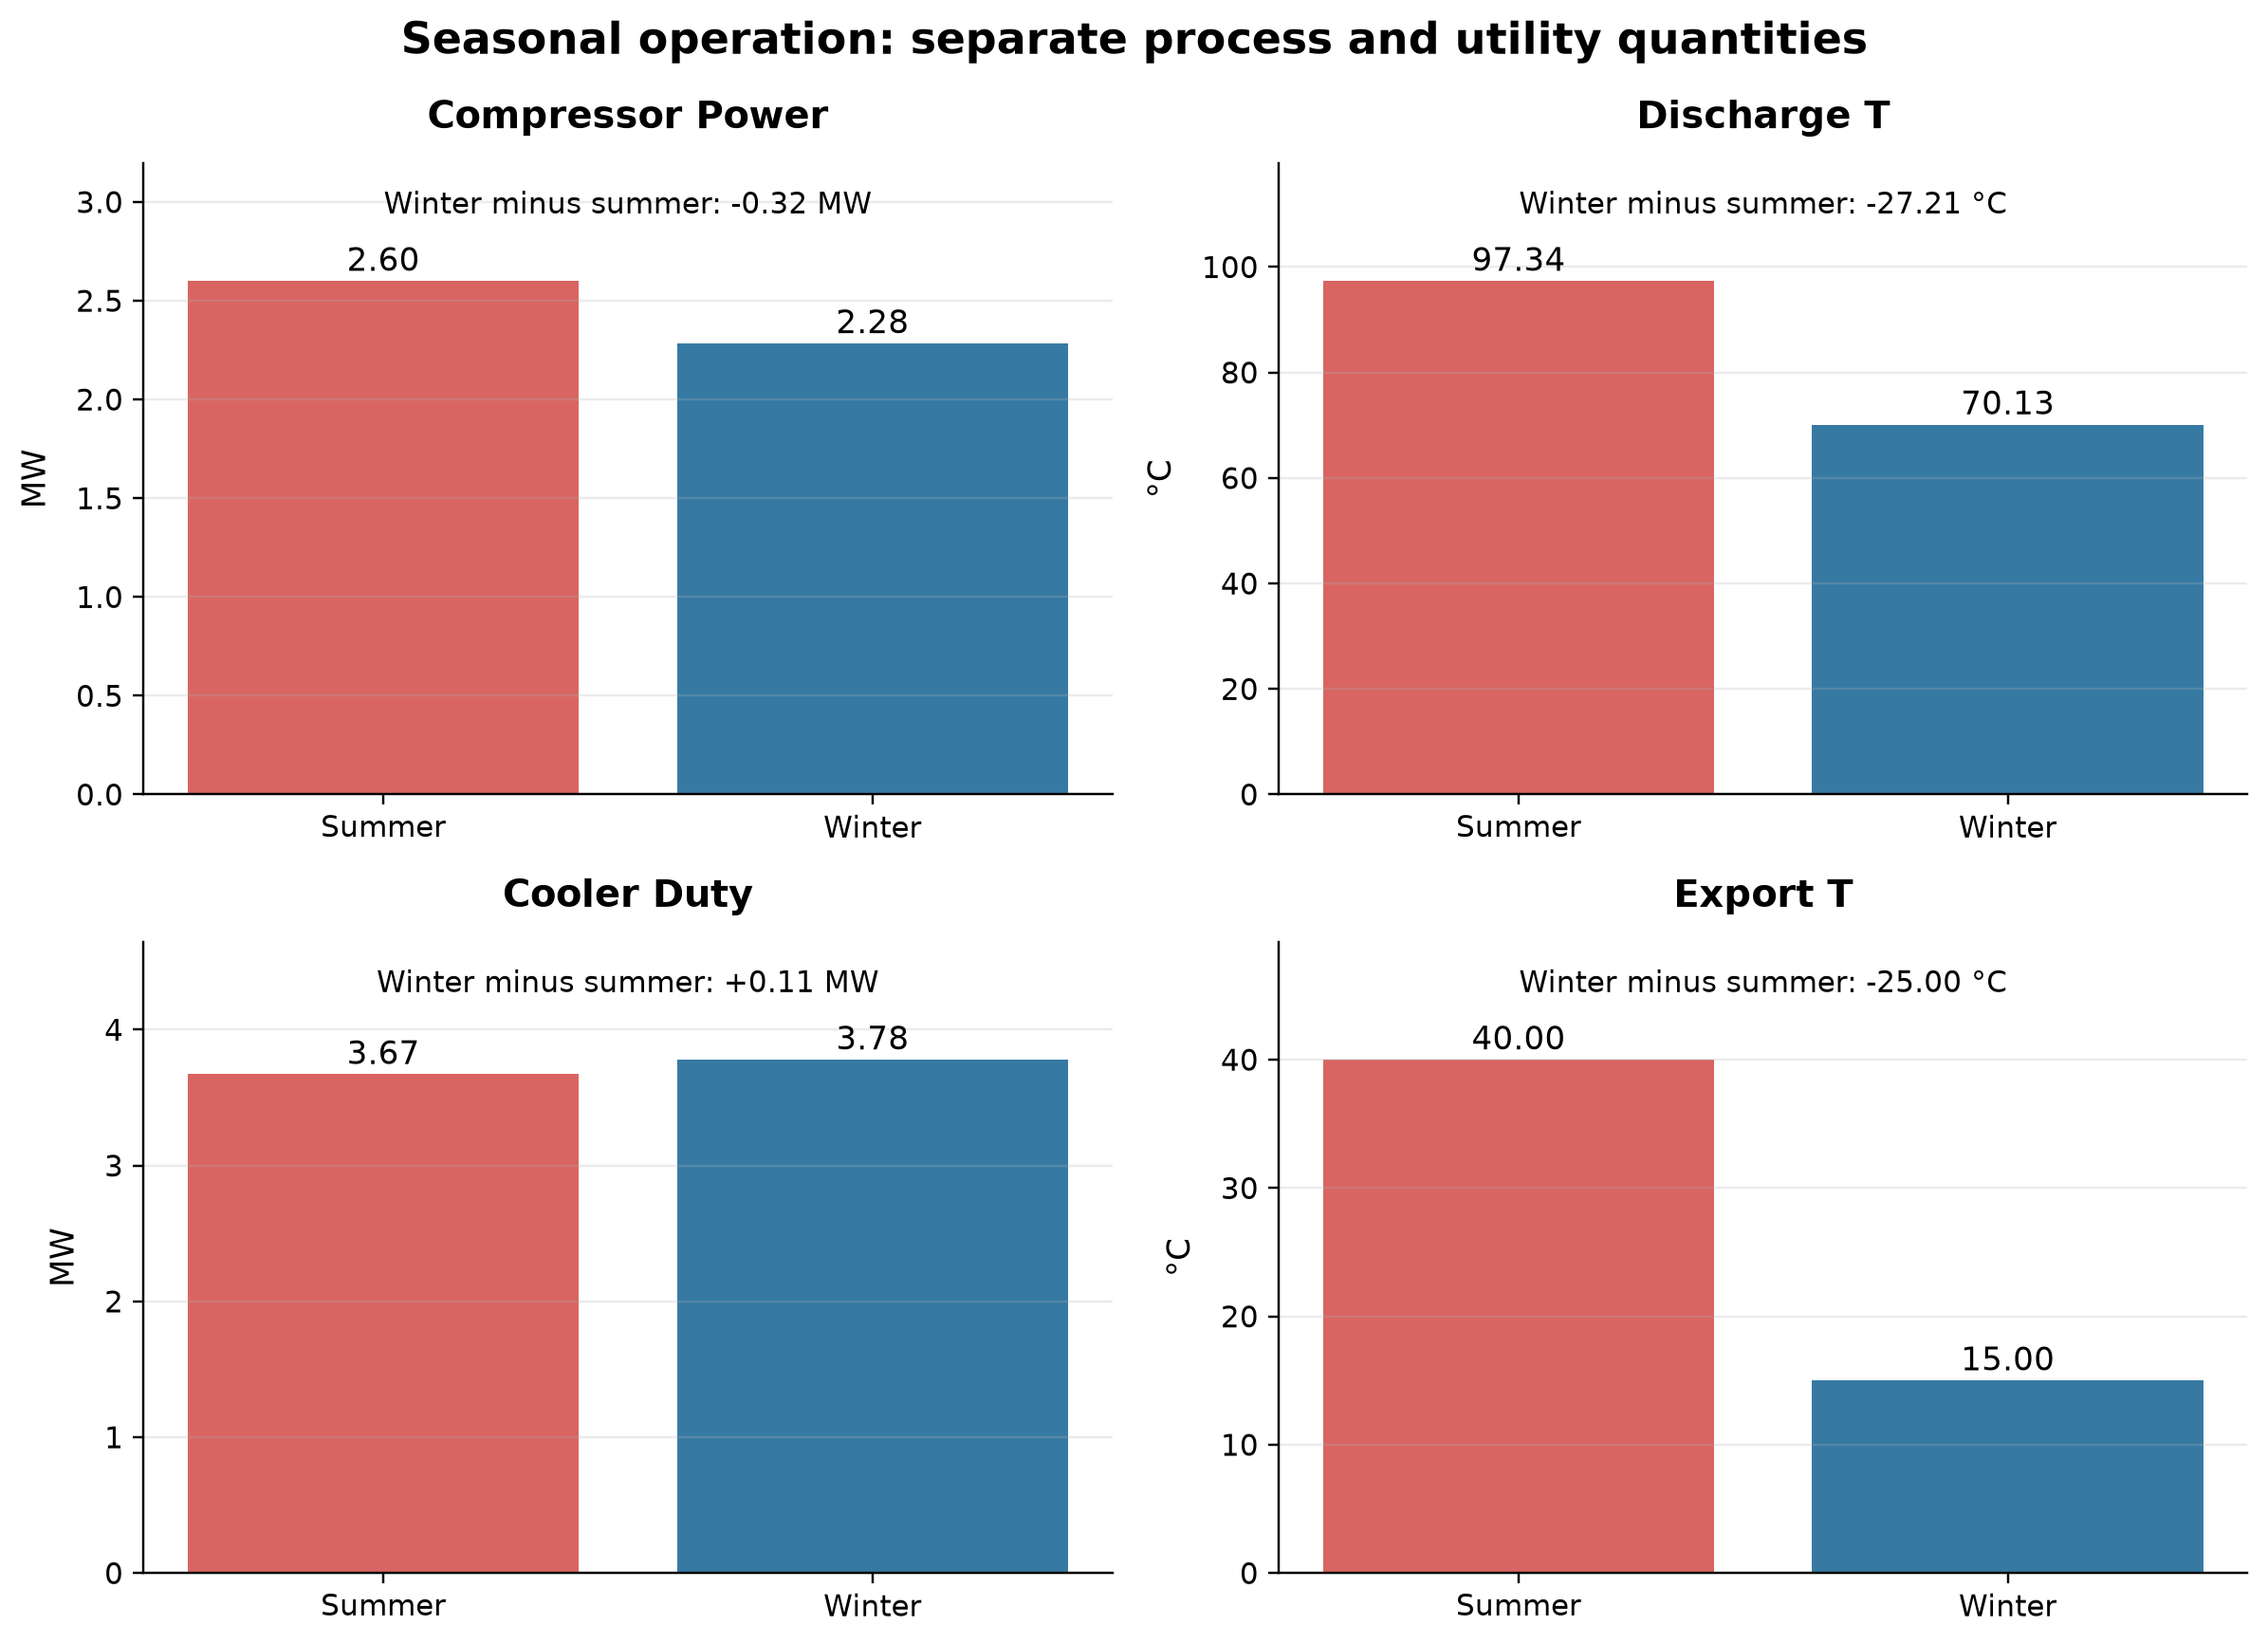

In [6]:
metrics = list(list(results.values())[0].keys())
scenario_names = list(results.keys())
summer_vals = [results[scenario_names[0]][m] for m in metrics]
winter_vals = [results[scenario_names[1]][m] for m in metrics]
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for axis, metric, summer, winter in zip(axes.flat, metrics, summer_vals, winter_vals):
    name, unit = metric.rsplit(' [', 1)
    unit = unit.rstrip(']').replace('C', '°C')
    bars = axis.bar(['Summer', 'Winter'], [summer, winter], color=['#D86562', '#367AA3'])
    axis.set_title(name)
    axis.set_ylabel(unit)
    axis.set_ylim(0, max(summer, winter)*1.23)
    axis.grid(True, axis='y', alpha=0.25)
    for bar, value in zip(bars, [summer, winter]):
        axis.text(bar.get_x()+bar.get_width()/2, value+max(summer,winter)*0.02,
                  f'{value:.2f}', ha='center')
    axis.text(0.5, 0.92, f'Winter minus summer: {winter-summer:+.2f} {unit}',
              transform=axis.transAxes, ha='center', fontsize=10)
fig.suptitle('Seasonal operation: separate process and utility quantities', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR/'ch22_scenario_comparison.png', dpi=220, bbox_inches='tight')
plt.show()
print('Metric | Summer | Winter | Difference (same unit)')
for metric, summer, winter in zip(metrics, summer_vals, winter_vals):
    print(f'{metric} | {summer:.4f} | {winter:.4f} | {winter-summer:+.4f}')


**Executed-figure discussion.** From summer to winter, compressor power changes from 2.600 to 2.284 MW and discharge temperature from 97.34 to 70.13 °C. Cooler duty changes from 3.672 to 3.779 MW, while export temperature changes from 40 to 15 °C.

The two NeqSim cases change the inlet temperature while holding the stated process configuration fixed. The separate panels preserve the distinction between shaft power, heat duty and temperature; lower inlet temperature reduces compression work in this case. Compare each quantity in its own unit and reconcile seasonal utility requirements with the actual cooling boundary.


## 32.4 Summary

**Key takeaways:**

1. **Multi-objective optimization** reveals trade-offs that single-objective methods miss.
2. The **Pareto front** shows the set of non-dominated solutions — no improvement in one
   objective is possible without worsening another.
3. **Scenario comparison** (summer vs winter) quantifies the impact of ambient conditions
   on plant performance — winter typically reduces compressor power due to colder inlet gas.
4. Decision-makers select operating points on the Pareto front based on economic and
   operational priorities.
5. NeqSim enables rapid evaluation of many operating scenarios for optimization studies.

## Numerical output and figure provenance
The following table is extracted from the plotted numerical data. Each saved figure has an adjacent CSV and JSON record; missing points remain visible and are not replaced by interpolated results. Extrema summarize the sampled operating envelope, and are not independent validation of the model.


In [7]:
figure_results = export_figure_summary(NOTEBOOK_PATH)
print(figure_results.to_string(index=False, float_format=lambda value: f'{value:.6g}'))


                      Figure  Panel                      Series               Output / unit  Minimum  Maximum  Finite points  Missing points
       ch22_pareto_front.png      1    Non-dominated candidates Total compressor power (MW)  1.29092  5.16367             10               0
       ch22_pareto_front.png      1 Dominated NeqSim candidates Total compressor power (MW)  1.46298  6.74983             20               0
ch22_scenario_comparison.png      1                      Bars 1                          MW  2.28407  2.59976              2               0
ch22_scenario_comparison.png      2                      Bars 1                          °C  70.1302  97.3403              2               0
ch22_scenario_comparison.png      3                      Bars 1                          MW  3.67168  3.77944              2               0
ch22_scenario_comparison.png      4                      Bars 1                          °C       15       40              2               0
